# TMDB — Örnek Kullanım

Bu notebook `src/` modüllerinin nasıl kullanıldığını gösterir.
Yeni bir dataset veya task type ile başlamak için yalnızca **Konfigürasyon** hücresini düzenle.

| Adım | Açıklama |
|------|----------|
| 1 | Kütüphaneler & import |
| 2 | Konfigürasyon |
| 3 | Eğitim |
| 4 | Tuning |
| 5 | Test değerlendirmesi |
| 6 | Rapor |

## 1 — Kütüphaneler

In [1]:
%pip install -q pandas numpy matplotlib mlflow shap lightgbm scikit-learn iterative-stratification ipywidgets optuna

Note: you may need to restart the kernel to use updated packages.


In [2]:
import importlib
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import mlflow
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

import src.modeling, src.evaluation, src.tuning, src.reporting, src.automl
for _mod in (src.modeling, src.evaluation, src.tuning, src.reporting, src.automl):
    importlib.reload(_mod)

from src.modeling import MAIN_METRIC, train_session, compare_models
from src.evaluation import evaluate_test
from src.tuning import tune_model
from src.reporting import generate_experiment_report

RANDOM_STATE = 42
print('✓ Hazır')

✓ Hazır


## 2 — Konfigürasyon

In [3]:
# ── Yeni bir proje için yalnızca bu hücreyi düzenle ───────────
DATASET_PATH     = 'data/tmdb_model.csv'
TASK_TYPE        = 'binary'   # binary | multiclass | regression | timeseries | multilabel
TARGET           = 'hit'
N_TRIALS         = 100
FEATURE_PREFIXES = ['genre_', 'kw_']
FEATURE_VERSION  = 'v8_company_hist'  # 30 özellik: v7 + company_hist_roi
SPLIT_MODE       = 'temporal'  # 'temporal' | 'random'

BASE_FEATURES = [
    # Bütçe & Prodüksiyon
    'budget', 'runtime',
    'num_companies',
    'is_major_studio', 'is_english', 'is_us_production',
    # Pazarlama
    'has_homepage',
    # Tür & Franchise
    'num_genres', 'is_franchise',
    # Takvim
    'is_summer', 'is_holiday',
    # Yönetmen & Oyuncu geçmişi (temporal safe)
    'director_film_count', 'director_collab_count',
    'director_hist_roi', 'actor_hist_roi',
    'director_hist_vote_avg', 'actor_hist_vote_avg',
    # Yapım şirketi geçmişi (temporal safe)
    'company_hist_roi',
]
# ──────────────────────────────────────────────────────────────

### Feature Seçimi

**Kural:** Modelde yalnızca filmin vizyona girmesinden **önce** kesin olarak bilinen özellikler kullanılır.

#### Kullanılan Özellikler (27 adet) — v4 Univariate Seçimi

| Grup | Sayı | Özellikler |
|------|------|-----------|
| Sayısal / meta | 8 | `budget`, `runtime`, `num_companies`, `num_genres`, `director_film_count`, `director_collab_count`, `director_hist_roi`, `actor_hist_roi` |
| Binary — yapısal | 7 | `is_major_studio`, `is_english`, `is_us_production`, `has_homepage`, `is_summer`, `is_holiday`, `is_franchise` |
| Binary — tür | 9 | `genre_Action`, `genre_Adventure`, `genre_Animation`, `genre_Documentary`, `genre_Drama`, `genre_Family`, `genre_Fantasy`, `genre_Horror`, `genre_Science Fiction` |
| Binary — keyword | 3 | `kw_3d`, `kw_sequel`, `kw_independent_film` |

**Notlar:**
- `director_film_count` / `director_collab_count` / `director_hist_roi` / `actor_hist_roi` — temporal safe: her film için yalnızca `release_date` öncesi filmler kullanılır
- `is_summer` = Haziran–Ağustos vizyonu; `is_holiday` = Kasım–Aralık vizyonu

#### Çıkarılan Özellikler

| Özellik | Gerekçe |
|---------|--------|
| `popularity`, `vote_average`, `vote_count` | Post-release — film izlendikten sonra TMDB'de oluşur |
| `has_postcredit` | Post-release — filmin izlenmesini gerektirir |
| `budget_log` | `budget` zaten mevcut; log dönüşümü tree modeller için gereksiz |
| `budget_per_minute` | Multikolinearite: `budget` ile r=0.969 |
| `tagline_length`, `overview_length`, `num_countries`, `num_languages` | Bonferroni anlamsız (p > 0.0010) |
| `kw_based_on_novel`, `kw_woman_director`, `kw_biography`, `kw_musical` | Bonferroni anlamsız (p > 0.0010) |
| 10 genre özelliği | Bonferroni anlamsız: `genre_Romance`, `genre_Crime`, `genre_History`, `genre_Western`, `genre_Mystery`, `genre_Comedy`, `genre_War`, `genre_Foreign`, `genre_Thriller`, `genre_Music` |
| `kw_aftercreditsstinger`, `kw_duringcreditsstinger` | Post-release — SHAP analizi: zayıf sinyal (mean_abs < 0.007), kullanıcılar izledikten sonra etiketler |
| `relative_budget_score` | SHAP çakışma: `budget` ile r=0.781, zıt SHAP yönleri — multikolinearite belirtisi (ADVBK-61) |
| `kw_murder`, `kw_dystopia`, vb. | Post-release — kullanıcıların film izledikten sonra eklediği içerik etiketleri |


### Veri Hazırlama *(dokunma)*

In [4]:
EXPERIMENT_NAME = Path(DATASET_PATH).stem
MLFLOW_URI = os.getenv('MLFLOW_TRACKING_URI', 'http://localhost:5000')
mlflow.set_tracking_uri(MLFLOW_URI)

df          = pd.read_csv(DATASET_PATH)
prefix_cols = [c for c in df.columns if any(c.startswith(p) for p in FEATURE_PREFIXES)]
FEATURES    = BASE_FEATURES + prefix_cols  # release_year intentionally excluded

df_model = df[FEATURES + [TARGET]]
X        = df_model[FEATURES]
y        = df_model[TARGET]

if SPLIT_MODE == 'temporal' and 'release_year' in df.columns:
    # Temporal split: ≤2009 train / 2010–2013 val / ≥2014 test  (~71%/19%/10%)
    TRAIN_CUTOFF = 2009
    VAL_CUTOFF   = 2013
    yr = df['release_year']
    mask_train = yr <= TRAIN_CUTOFF
    mask_val   = (yr > TRAIN_CUTOFF) & (yr <= VAL_CUTOFF)
    mask_test  = yr > VAL_CUTOFF
    X_train = X[mask_train].reset_index(drop=True)
    y_train = y[mask_train].reset_index(drop=True)
    X_val   = X[mask_val].reset_index(drop=True)
    y_val   = y[mask_val].reset_index(drop=True)
    X_test  = X[mask_test].reset_index(drop=True)
    y_test  = y[mask_test].reset_index(drop=True)
    split_desc = f'temporal (≤{TRAIN_CUTOFF} / {TRAIN_CUTOFF+1}–{VAL_CUTOFF} / ≥{VAL_CUTOFF+1})'
elif TASK_TYPE == 'timeseries':
    n = len(X)
    X_train = X.iloc[:int(n * 0.70)]
    X_val   = X.iloc[int(n * 0.70):int(n * 0.85)]
    X_test  = X.iloc[int(n * 0.85):]
    y_train = y.iloc[:int(n * 0.70)]
    y_val   = y.iloc[int(n * 0.70):int(n * 0.85)]
    y_test  = y.iloc[int(n * 0.85):]
    split_desc = 'timeseries (positional 70/15/15)'
else:
    stratify = y if TASK_TYPE in ('binary', 'multiclass') else None
    # 3-way split: 70 / 15 / 15
    X_temp, X_test, y_temp, y_test = train_test_split(
        X, y, test_size=0.15, stratify=stratify, random_state=RANDOM_STATE,
    )
    val_frac = 0.15 / 0.85  # ~17.6% of temp → ~15% of total
    X_train, X_val, y_train, y_val = train_test_split(
        X_temp, y_temp, test_size=val_frac,
        stratify=y_temp if TASK_TYPE in ('binary', 'multiclass') else None,
        random_state=RANDOM_STATE,
    )
    split_desc = 'random stratified (70/15/15)'

# Hist features NaN imputation — train medyanı ile (leakage-free)
_hist_cols = [c for c in FEATURES if 'hist' in c]
if _hist_cols:
    _medians = X_train[_hist_cols].median()
    X_train = X_train.copy()
    X_val   = X_val.copy()
    X_test  = X_test.copy()
    X_train[_hist_cols] = X_train[_hist_cols].fillna(_medians)
    X_val[_hist_cols]   = X_val[_hist_cols].fillna(_medians)
    X_test[_hist_cols]  = X_test[_hist_cols].fillna(_medians)
    print(f'NaN imputation: {_hist_cols} → train medyanı kullanıldı')

print(f'Dataset  : {DATASET_PATH}')
print(f'Task     : {TASK_TYPE}')
print(f'Split    : {split_desc}')
print(f'Toplam   : {len(df_model):,}  |  hit oranı: %{y.mean()*100:.1f}')
print(f'Train    : {len(X_train):,}  ({len(X_train)/len(df_model)*100:.0f}%)  |  hit: %{y_train.mean()*100:.1f}')
print(f'Val      : {len(X_val):,}  ({len(X_val)/len(df_model)*100:.0f}%)  |  hit: %{y_val.mean()*100:.1f}')
print(f'Test     : {len(X_test):,}  ({len(X_test)/len(df_model)*100:.0f}%)  |  hit: %{y_test.mean()*100:.1f}')
print(f'Özellik  : {len(FEATURES)}')

NaN imputation: ['director_hist_roi', 'actor_hist_roi', 'director_hist_vote_avg', 'actor_hist_vote_avg', 'company_hist_roi'] → train medyanı kullanıldı
Dataset  : data/tmdb_model.csv
Task     : binary
Split    : temporal (≤2009 / 2010–2013 / ≥2014)
Toplam   : 3,226  |  hit oranı: %34.8
Train    : 2,281  (71%)  |  hit: %32.2
Val      : 618  (19%)  |  hit: %37.5
Test     : 327  (10%)  |  hit: %48.3
Özellik  : 30


## 3 — Baseline Eğitimi

Eğitim başlıyor  —  experiment: "tmdb_model"  |  oturum: session_A_20260426_1909  |  task: binary


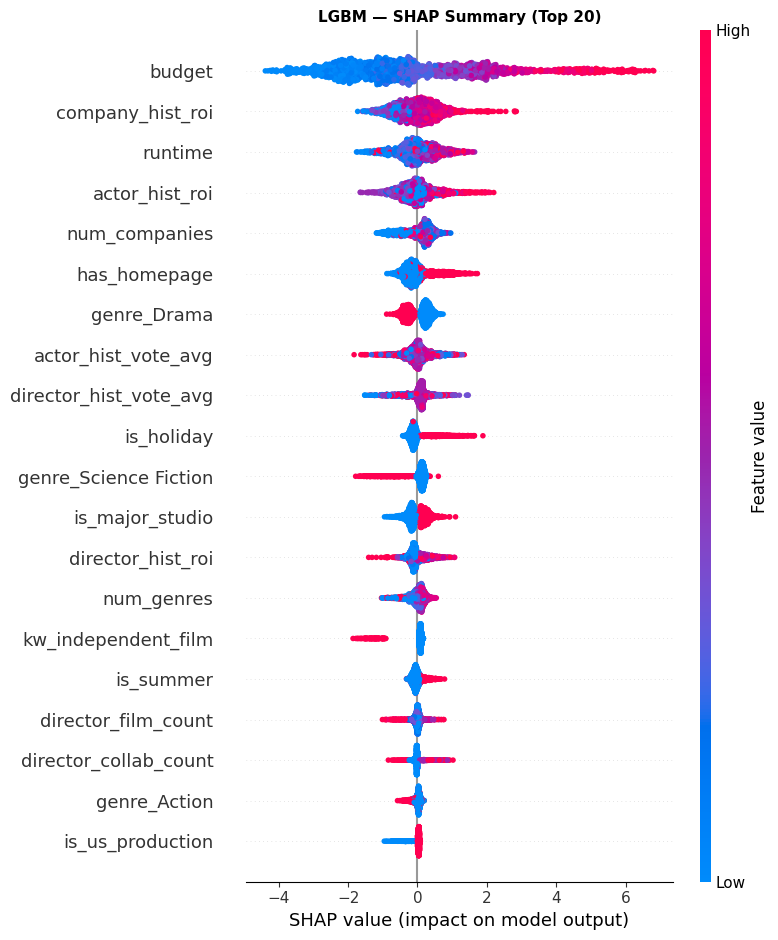

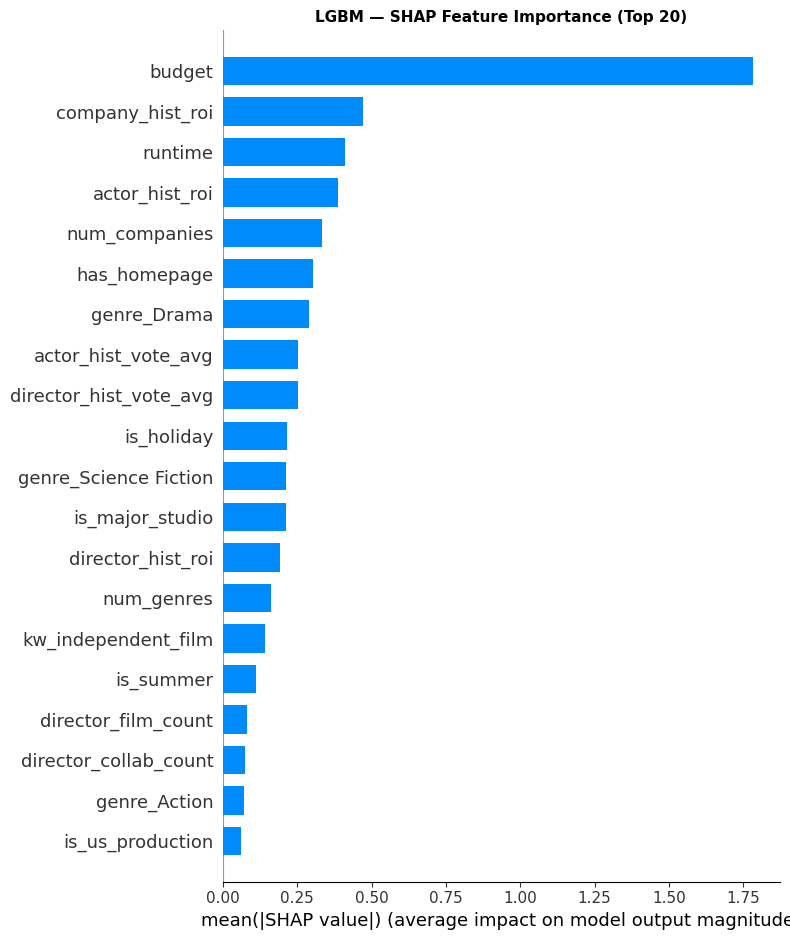

  ✓ baseline_lgbm_20260426_1909                        train=1.000  val=0.725  gap=+0.275
🏃 View run baseline_lgbm_20260426_1909 at: http://localhost:5000/#/experiments/1/runs/4b6fa981d87049edba1305a5de402ed5
🧪 View experiment at: http://localhost:5000/#/experiments/1


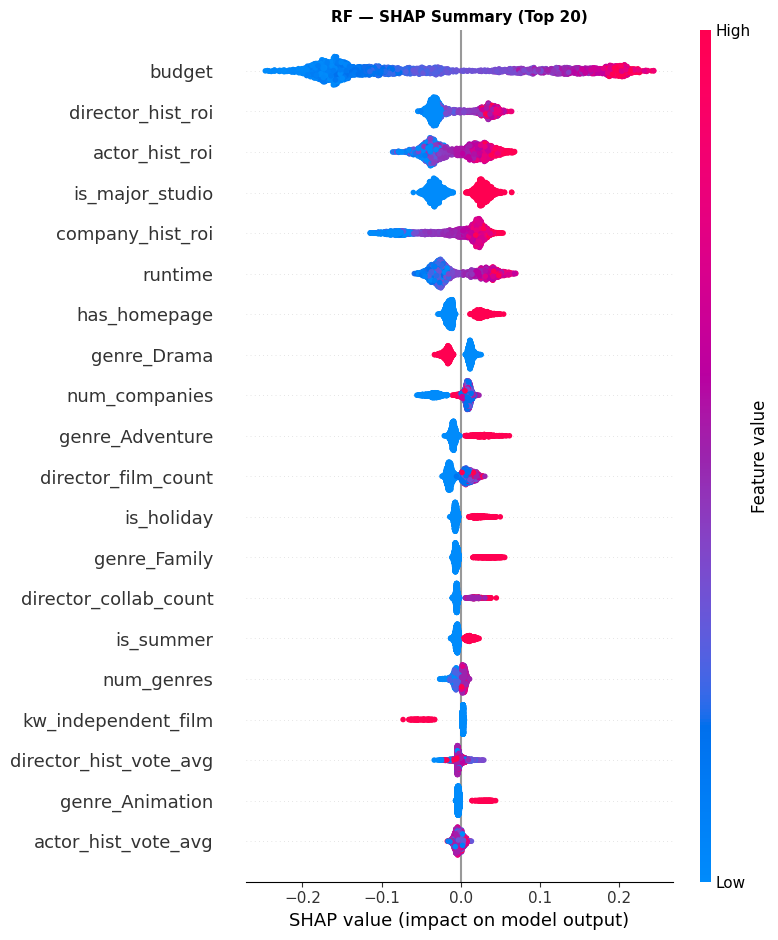

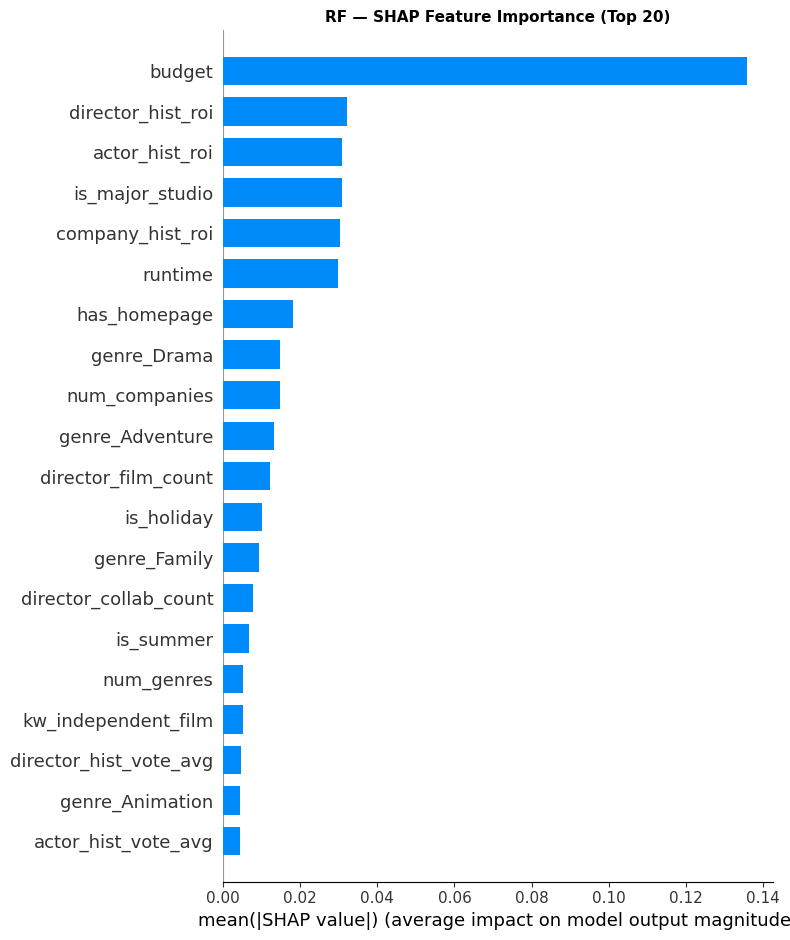

  ✓ baseline_rf_20260426_1909                          train=0.869  val=0.741  gap=+0.128
🏃 View run baseline_rf_20260426_1909 at: http://localhost:5000/#/experiments/1/runs/118fce7f20ad47b7afdfb1c17bc68b9a
🧪 View experiment at: http://localhost:5000/#/experiments/1


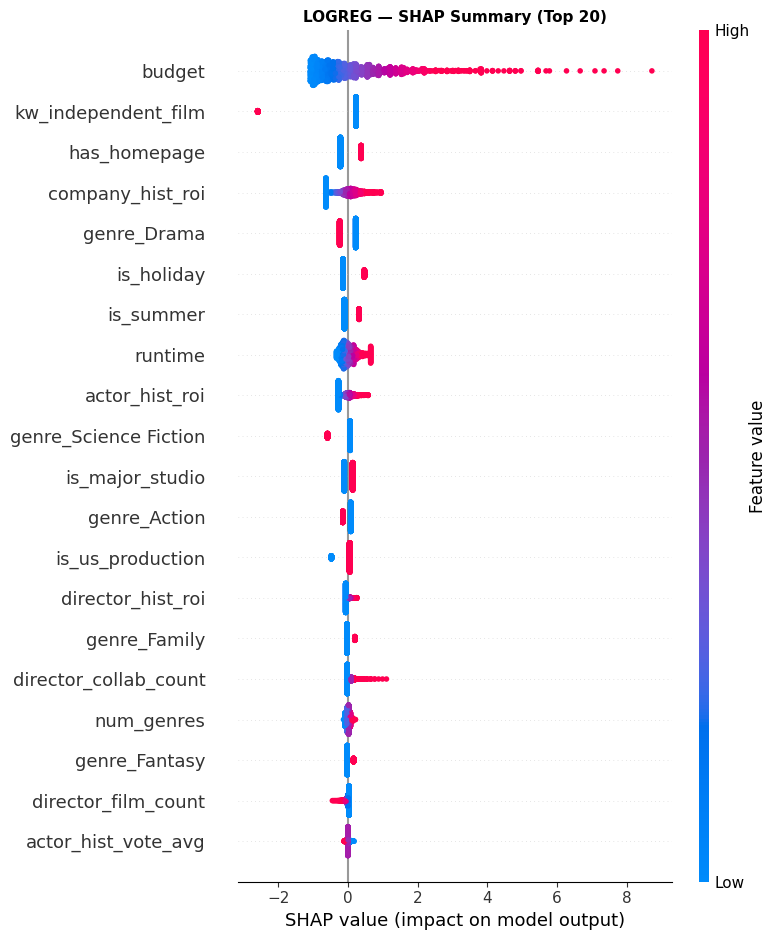

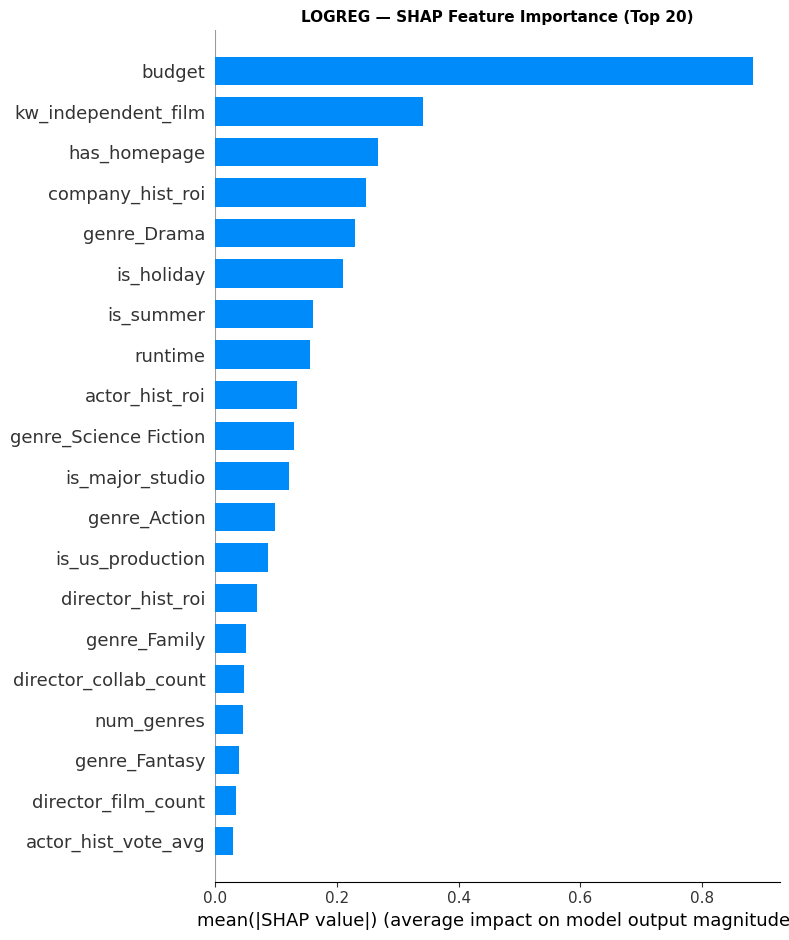

  ✓ baseline_logreg_20260426_1910                      train=0.755  val=0.742  gap=+0.013
🏃 View run baseline_logreg_20260426_1910 at: http://localhost:5000/#/experiments/1/runs/a835de0b3e32488a877737f3837d8806
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run session_A_20260426_1909 at: http://localhost:5000/#/experiments/1/runs/d54dac65efed419fbab6fc9c61a21bb5
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ Oturum tamamlandı


In [5]:
MODEL_CONFIGS = {
    'lgbm': lambda ir: LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    ),
    'rf': lambda ir: RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    ),
    'logreg': lambda ir: Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ]),
}

models, results = train_session(
    DATASET_PATH, MODEL_CONFIGS, X_train, y_train,
    task_type=TASK_TYPE, scenario='A',
)

=== Model Karşılaştırma Tablosu ===


,ROC_AUC,F1,PRECISION,RECALL,AVG_PREC
Model,,,,,
lgbm,0.821,0.636,0.660,0.616,0.725
rf,0.837,0.658,0.623,0.700,0.741
logreg,0.841,0.675,0.619,0.744,0.742



🏆 En iyi model: logreg  (avg_prec=0.742)
🏃 View run comparison_chart at: http://localhost:5000/#/experiments/1/runs/41633bcdcb8e4e6088c970ab57cec3bd
🧪 View experiment at: http://localhost:5000/#/experiments/1


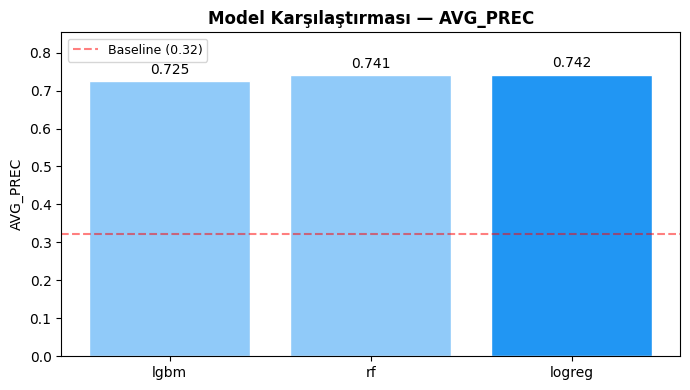


=== Overfitting / Underfitting Analizi ===


,Train AVG_PREC,Val AVG_PREC,Gap (Train−Val)
Model,,,
lgbm,1.000,0.725,0.275
rf,0.869,0.741,0.128
logreg,0.755,0.742,0.013


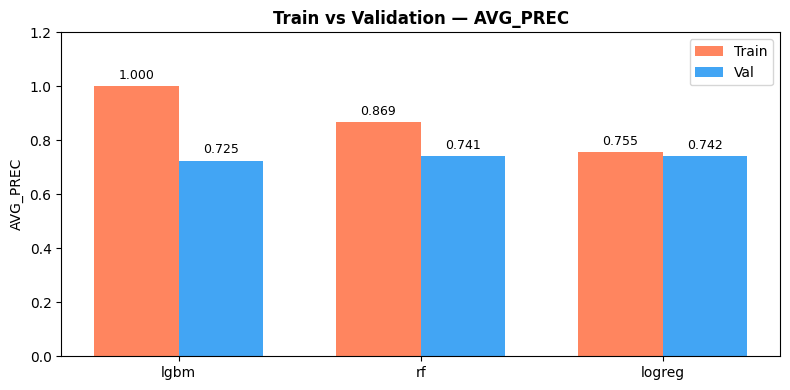

  ⚠️  lgbm: ciddi overfit (gap=0.275 > 0.2) — dışlandı
  ✓ Geçerli modeller: ['rf', 'logreg'] — en iyi: logreg


In [6]:
main_metric = MAIN_METRIC[TASK_TYPE]
best        = compare_models(results, TASK_TYPE, EXPERIMENT_NAME, y_train)
best_model  = models[best]

## 4 — Hiperparametre Tuning (Tüm Modeller)

In [7]:
from src.automl import tune_all_models

ir = (y_train == 0).sum() / (y_train == 1).sum()

def lgbm_temporal_fn(trial):
    """Temporal split için yüksek regularization LGBM search space."""
    from lightgbm import LGBMClassifier
    max_depth = trial.suggest_int('max_depth', 3, 5)
    return LGBMClassifier(
        n_estimators      = trial.suggest_int('n_estimators', 300, 1000),
        learning_rate     = trial.suggest_float('learning_rate', 0.01, 0.05, log=True),
        max_depth         = max_depth,
        num_leaves        = trial.suggest_int('num_leaves', 8, 2**max_depth),
        min_child_samples = trial.suggest_int('min_child_samples', 30, 100),
        reg_alpha         = trial.suggest_float('reg_alpha', 1.0, 50.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda', 1.0, 50.0, log=True),
        subsample         = trial.suggest_float('subsample', 0.5, 0.8),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5, 0.8),
        scale_pos_weight  = ir,
        random_state      = RANDOM_STATE,
        verbose           = -1,
        n_jobs            = 1,
    )

best_model, best, tuned_models, ensemble_candidates = tune_all_models(
    results           = results,
    X                 = X_train,
    y                 = y_train,
    task_type         = TASK_TYPE,
    n_trials          = N_TRIALS,
    max_gap           = 0.10,
    model_fn_map      = {'lgbm': lgbm_temporal_fn},
    X_val             = X_val,
    y_val             = y_val,
    jaccard_threshold = 0.60,
    feature_version   = FEATURE_VERSION,
)

if ensemble_candidates:
    print(f"\nEnsemble adayları: {list(ensemble_candidates.keys())}")


── Tuning: rf  (baseline=0.7406  min_improvement=0.0235) ──
Optuna başlıyor — model: rf  |  metrik: avg_prec  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7406
  Tuned     avg_prec: 0.7408
  İyileşme : +0.0002

  En iyi parametreler:
    n_estimators: 126
    max_depth: 7
    min_samples_leaf: 11
    max_features: sqrt
  Train-val gap: 0.0950  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_rf_20260426_1912 at: http://localhost:5000/#/experiments/1/runs/c379e687fb0344afa0c03e56537b27cf
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned rf
  — rf: iyileşme yetersiz (+0.0002 < 0.0235) — elendi

── Tuning: logreg  (baseline=0.7421  min_improvement=0.0127) ──
Optuna başlıyor — model: logreg  |  metrik: avg_prec  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7421
  Tuned     avg_prec: 0.7434
  İyileşme : +0.0014

  En iyi parametreler:
    C: 0.029925140295637566
  Train-val gap: 0.0111  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_logreg_20260426_1912 at: http://localhost:5000/#/experiments/1/runs/c3e3712595d548d88e3fefdd42fb3095
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned logreg
  — logreg: iyileşme yetersiz (+0.0013 < 0.0127) — elendi

⚠️  Recovery tuning: ['lgbm']  (eşik=0.2)

── Recovery Tuning: lgbm ──
Optuna başlıyor — model: lgbm  |  metrik: avg_prec  |  trial: 100  |  max_gap: 0.1


  0%|          | 0/100 [00:00<?, ?it/s]


✓ Tuning tamamlandı
  Baseline  avg_prec: 0.7247
  Tuned     avg_prec: 0.7500
  İyileşme : +0.0254

  En iyi parametreler:
    max_depth: 5
    n_estimators: 933
    learning_rate: 0.034687037669159905
    num_leaves: 21
    min_child_samples: 37
    reg_alpha: 10.754926950192944
    reg_lambda: 4.850365043944277
    subsample: 0.6863405422748043
    colsample_bytree: 0.708984251145191
  Train-val gap: 0.0822  (✓ eşik altı)
✓ Tuning sonuçları ve model MLflow'a kaydedildi
🏃 View run tuning_lgbm_20260426_1914 at: http://localhost:5000/#/experiments/1/runs/117e4eef21744669ae604030b7a67ea1
🧪 View experiment at: http://localhost:5000/#/experiments/1

✓ best_model güncellendi — tuned lgbm
  ✓ lgbm: recovery başarılı (0.7500 > 0.7434) — best model güncellendi

✓ tune_all_models tamamlandı — best: lgbm  (avg_prec=0.7500)

── Ensemble Aday Analizi (Jaccard eşik=0.6) ──
  lgbm ↔ rf: Jaccard=0.76 → atlandı (>0.6)
  lgbm ↔ logreg: Jaccard=0.59 → ensemble adayı ✓

Ensemble adayları: ['logreg']


## 5 — Test Değerlendirmesi

              precision    recall  f1-score   support

           0       0.83      0.82      0.83       169
           1       0.81      0.82      0.82       158

    accuracy                           0.82       327
   macro avg       0.82      0.82      0.82       327
weighted avg       0.82      0.82      0.82       327


=== Test Metrikleri ===
  PR-AUC      : 0.9031
  ROC-AUC     : 0.8966
  F1          : 0.8176
  Precision   : 0.8125
  Recall      : 0.8228

=== LGBM — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.725,0.903,0.178
ROC-AUC,0.821,0.897,0.076
F1,0.636,0.818,0.182
Precision,0.660,0.812,0.152
Recall,0.616,0.823,0.207


🏃 View run test_eval_lgbm_20260426_1914 at: http://localhost:5000/#/experiments/1/runs/fe44a60dc407480d90fde5a1098bc15a
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


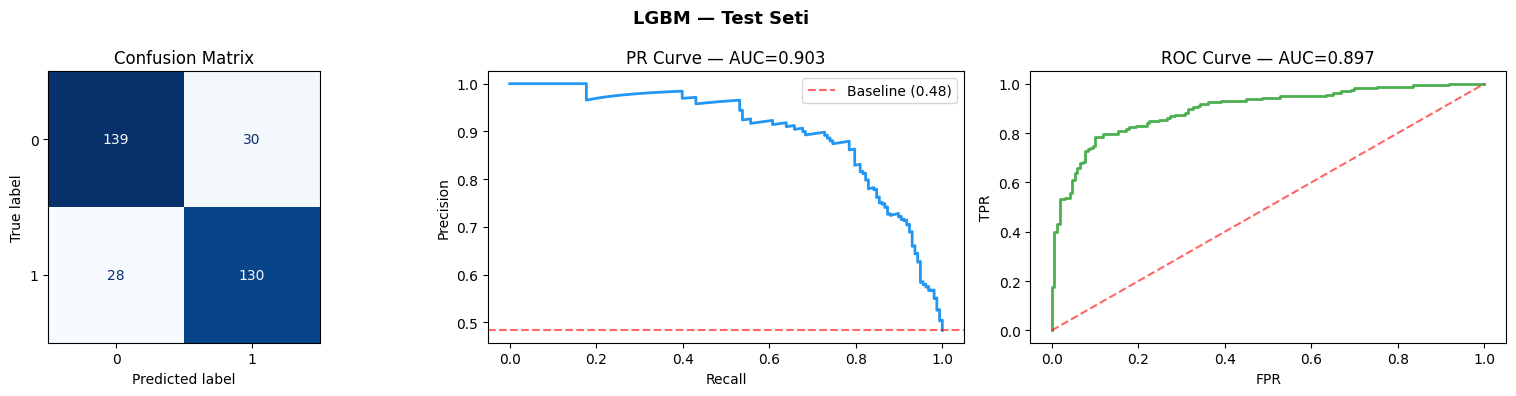

In [8]:
test_metrics = evaluate_test(
    best_model, X_test, y_test, TASK_TYPE, best,
    cv_metrics      = results[best]['val'],
    experiment_name = EXPERIMENT_NAME,
    feature_version = FEATURE_VERSION,
    features        = FEATURES,
    extra_tags      = {"selection_method": "val_based", "split_mode": SPLIT_MODE},
)


## 6 — Rapor

In [9]:
from IPython.display import Markdown, display

report = generate_experiment_report(
    experiment_name = EXPERIMENT_NAME,
    task_type       = TASK_TYPE,
    dataset_path    = DATASET_PATH,
    n_samples       = len(df_model),
    hit_rate        = y.mean(),
    n_features      = len(FEATURES),
)

display(Markdown(report))

✓ Rapor oluşturuldu → experiment_report_20260426_191422.md
✓ MLflow'a kaydedildi → docs/experiment_report_20260426_191422.md
🏃 View run report_20260426_1914 at: http://localhost:5000/#/experiments/1/runs/52092253f4c9497c967f479396f3b848
🧪 View experiment at: http://localhost:5000/#/experiments/1


# Experiment Raporu — tmdb_model

**Oluşturulma:** 2026-04-26 19:14  
**Task:** binary  
**Ana Metrik:** avg_prec  
**Dataset:** data/tmdb_model.csv  
**Toplam Film:** 3,226  |  **Hit Oranı:** %34.8  
**Özellik Sayısı:** 30  

---

## Baseline Sonuçları

| Model | PR-AUC | ROC-AUC | F1 | Precision | Recall |
|-------|--------|---------|----|-----------|----|
| logreg | 0.742 | 0.841 | 0.675 | 0.619 | 0.744 |
| rf | 0.741 | 0.837 | 0.658 | 0.623 | 0.700 |
| lgbm | 0.725 | 0.821 | 0.636 | 0.660 | 0.616 |

---

## Tuning

- **lgbm** — Baseline avg_prec: 0.725 → Tuned: 0.750 (İyileşme: 0.025)
- **logreg** — Baseline avg_prec: 0.742 → Tuned: 0.743 (İyileşme: 0.001)
- **rf** — Baseline avg_prec: 0.741 → Tuned: 0.741 (İyileşme: 0.000)

---

## Test Seti Sonuçları

| Metrik | Değer |
|--------|-------|
| PR_AUC | 0.903 |
| ROC_AUC | 0.897 |
| F1 | 0.818 |
| RECALL | 0.823 |
| PRECISION | 0.812 |

## 7 — Hibrit Modeller

Baseline modellerin (LGBM, RF, LogReg) güçlü yönlerini birleştirmek için üç strateji deneniyor.

| Yöntem | Fikir | Artısı | Eksi |
|--------|-------|--------|------|
| **Voting** | Olasılıkların ağırlıklı ortalaması | Basit, hızlı, yorumlanabilir | Modeller aynı hatayı paylaşabilir |
| **Stacking** | CV ile out-of-fold meta-özellik → meta-model | En güçlü kombinasyon | Yavaş, dikkatli CV gerektirir |
| **Blending** | Holdout meta-özellik → meta-model (CV yok) | Hızlı, leakage riski düşük | Daha az veri verimli |

In [10]:
import numpy as np
from sklearn.base import clone
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score, f1_score, precision_score, recall_score

ir = (y_train == 0).sum() / (y_train == 1).sum()

def make_lgbm():
    return LGBMClassifier(
        n_estimators=400, learning_rate=0.05, num_leaves=31,
        min_child_samples=20, scale_pos_weight=ir,
        random_state=RANDOM_STATE, verbose=-1, n_jobs=1,
    )

def make_rf():
    return RandomForestClassifier(
        n_estimators=300, max_depth=10, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1,
    )

def make_logreg():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            C=0.1, class_weight='balanced',
            max_iter=1000, random_state=RANDOM_STATE,
        )),
    ])

def quick_val_metrics(model, X, y):
    """Val/test seti için sızıntısız metrik hesabı — MLflow kaydı yok."""
    proba = model.predict_proba(X)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    return {
        "PR-AUC":    average_precision_score(y, proba),
        "ROC-AUC":   roc_auc_score(y, proba),
        "F1":        f1_score(y, pred, zero_division=0),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall":    recall_score(y, pred, zero_division=0),
    }

print(f'✓ Base model factory hazır  |  imbalance_ratio: {ir:.3f}')
print('✓ quick_val_metrics hazır')

✓ Base model factory hazır  |  imbalance_ratio: 2.108
✓ quick_val_metrics hazır


### 7a — Voting Ensemble

`VotingClassifier(voting='soft')` her modelin olasılık tahminlerini ağırlıklı ortalamayla birleştirir.
LGBM baseline'da en güçlü performansı gösterdiği için `weights=[2, 1, 1]` kullanıyoruz.

In [11]:
# Top-2 seçimi: val avg_prec sıralaması
ranked = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)[:2]

scores  = {name: results[name]["val"]["avg_prec"] for name in ranked}
weights = [scores[name] for name in ranked]

print(f"Voting top-2 : {ranked}")
print(f"Weights      : {[f'{w:.4f}' for w in weights]}")

voting_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked],
    voting="soft",
    weights=weights,
    n_jobs=1,
)
voting_clf.fit(X_train, y_train)
voting_val_metrics = quick_val_metrics(voting_clf, X_val, y_val)

# Top-3: tüm tuned modeller
ranked3  = sorted(
    tuned_models.keys(),
    key=lambda name: results.get(name, {}).get("val", {}).get("avg_prec", 0),
    reverse=True,
)
scores3  = {name: results[name]["val"]["avg_prec"] for name in ranked3}
weights3 = [scores3[name] for name in ranked3]

print(f"\nVoting top-3 : {ranked3}")
print(f"Weights      : {[f'{w:.4f}' for w in weights3]}")

voting3_clf = VotingClassifier(
    estimators=[(name, clone(tuned_models[name])) for name in ranked3],
    voting="soft",
    weights=weights3,
    n_jobs=1,
)
voting3_clf.fit(X_train, y_train)
voting3_val_metrics = quick_val_metrics(voting3_clf, X_val, y_val)

display(pd.DataFrame([
    {"Model": "voting_top2", **{k: round(v, 4) for k, v in voting_val_metrics.items()}},
    {"Model": "voting_top3", **{k: round(v, 4) for k, v in voting3_val_metrics.items()}},
]).set_index("Model"))


Voting top-2 : ['logreg', 'rf']
Weights      : ['0.7421', '0.7406']

Voting top-3 : ['logreg', 'rf', 'lgbm']
Weights      : ['0.7421', '0.7406', '0.7247']


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
voting_top2,0.8543,0.8953,0.7683,0.7269,0.8147
voting_top3,0.8468,0.8942,0.7677,0.7224,0.8190


### 7b — Stacking

`StackingClassifier` her base modeli 5-fold CV ile eğitip out-of-fold tahminlerini
meta-özellik olarak kullanır. Meta-model (LogisticRegression) bu özelliklerden öğrenir.

In [12]:
stacking_clf = StackingClassifier(
    estimators=[
        ('lgbm',   clone(tuned_models['lgbm'])),
        ('rf',     clone(tuned_models['rf'])),
        ('logreg', clone(tuned_models['logreg'])),
    ],
    final_estimator=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    cv=5,
    stack_method='predict_proba',
    passthrough=False,
    n_jobs=1,
)
stacking_clf.fit(X_train, y_train)
stacking_val_metrics = quick_val_metrics(stacking_clf, X_val, y_val)
display(pd.DataFrame([{"Model": "stacking", **{k: round(v, 4) for k, v in stacking_val_metrics.items()}}]).set_index("Model"))


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
stacking,0.8554,0.8955,0.7763,0.8252,0.7328


### 7c — Blending

Train setinin %20'si **holdout** olarak ayrılır. Base modeller kalan %80 üzerinde eğitilir;
holdout tahminleri meta-model için girdi oluşturur. Stacking'e kıyasla daha hızlı ama
daha az veri verimlidir.

In [13]:
class BlendingEnsemble:
    """
    Blending stratejisi:
      1. X_train → blend_train (%80) + holdout (%20) olarak bölünür.
      2. Base modeller yalnızca blend_train üzerinde eğitilir.
      3. Holdout tahminleri (predict_proba) meta-özellik matrisini oluşturur.
      4. Meta-model bu matris üzerinde eğitilir.
      5. Test tahminleri: base modeller test setini tahmin eder → meta-model birleştirir.

    Stacking'den farkı: CV yoktur; bilgi sızıntısını önlemek için ayrı bir holdout kullanılır.
    """

    def __init__(self, base_models: list, meta_model, blend_ratio: float = 0.2,
                 random_state: int = 42):
        self.base_models  = base_models   # [(isim, estimator), ...]
        self.meta_model   = meta_model
        self.blend_ratio  = blend_ratio
        self.random_state = random_state

    def fit(self, X, y):
        from sklearn.model_selection import train_test_split
        X_bt, X_hold, y_bt, y_hold = train_test_split(
            X, y,
            test_size=self.blend_ratio,
            stratify=y,
            random_state=self.random_state,
        )
        for _, m in self.base_models:
            m.fit(X_bt, y_bt)

        meta_train = np.column_stack([
            m.predict_proba(X_hold)[:, 1] for _, m in self.base_models
        ])
        self.meta_model.fit(meta_train, y_hold)
        return self

    def predict_proba(self, X):
        meta = np.column_stack([
            m.predict_proba(X)[:, 1] for _, m in self.base_models
        ])
        prob1 = self.meta_model.predict_proba(meta)[:, 1]
        return np.column_stack([1 - prob1, prob1])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

print('✓ BlendingEnsemble sınıfı tanımlandı')

✓ BlendingEnsemble sınıfı tanımlandı


In [14]:
blending_clf = BlendingEnsemble(
    base_models=[(name, clone(tuned_models[name])) for name in tuned_models],
    meta_model=LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE),
    blend_ratio=0.2,
    random_state=RANDOM_STATE,
)
blending_clf.fit(X_train, y_train)
blending_val_metrics = quick_val_metrics(blending_clf, X_val, y_val)
display(pd.DataFrame([{"Model": "blending", **{k: round(v, 4) for k, v in blending_val_metrics.items()}}]).set_index("Model"))


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
blending,0.8419,0.8905,0.7593,0.82,0.7069


### Tüm Hibrit Modellerin Karşılaştırması

=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===


,PR-AUC,ROC-AUC,F1,Precision,Recall
Model,,,,,
best_single (lgbm),0.8157,0.8849,0.7661,0.7197,0.8190
voting_top2,0.8543,0.8953,0.7683,0.7269,0.8147
voting_top3,0.8468,0.8942,0.7677,0.7224,0.8190
stacking,0.8554,0.8955,0.7763,0.8252,0.7328
blending,0.8419,0.8905,0.7593,0.8200,0.7069


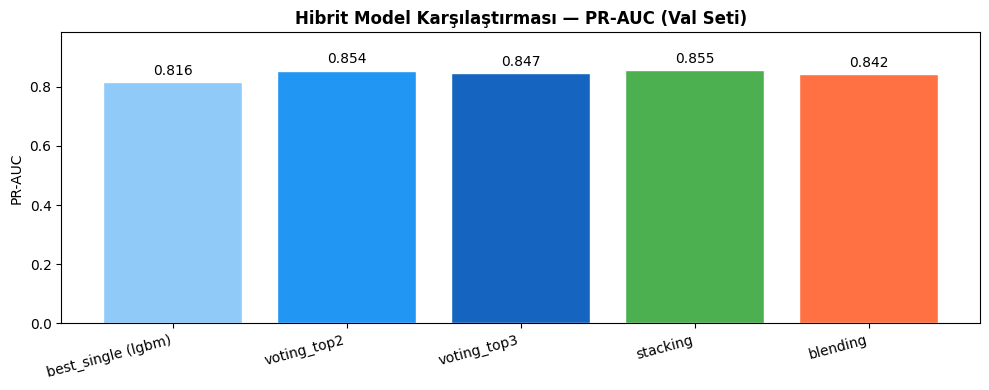

In [15]:
metric_col = "PR-AUC"
best_single_val_metrics = quick_val_metrics(best_model, X_val, y_val)

hybrid_val_results = {
    f"best_single ({best})": best_single_val_metrics,
    "voting_top2":           voting_val_metrics,
    "voting_top3":           voting3_val_metrics,
    "stacking":              stacking_val_metrics,
    "blending":              blending_val_metrics,
}

rows = []
for name, m in hybrid_val_results.items():
    rows.append({"Model": name, **{k: round(v, 4) for k, v in m.items()}})
comparison_df = pd.DataFrame(rows).set_index("Model")
print("=== Hibrit Model Karşılaştırması (Val Seti — Sızıntısız) ===")
display(comparison_df)

vals   = [m.get(metric_col, 0) for m in hybrid_val_results.values()]
labels = list(hybrid_val_results.keys())
colors = ["#90CAF9", "#2196F3", "#1565C0", "#4CAF50", "#FF7043"]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, vals, color=colors, edgecolor="white")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=10)
ax.set_title(f"Hibrit Model Karşılaştırması — {metric_col} (Val Seti)", fontsize=12, fontweight="bold")
ax.set_ylim(0, max(vals) * 1.15)
ax.set_ylabel(metric_col)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

### Final Model Seçimi

=== Final Model (val seti seçimi — sızıntısız) ===
  Model       : stacking
  Val PR-AUC : 0.8554

              precision    recall  f1-score   support

           0       0.76      0.92      0.83       169
           1       0.89      0.70      0.78       158

    accuracy                           0.81       327
   macro avg       0.83      0.81      0.81       327
weighted avg       0.82      0.81      0.81       327


=== Test Metrikleri ===
  PR-AUC      : 0.9061
  ROC-AUC     : 0.8969
  F1          : 0.7801
  Precision   : 0.8871
  Recall      : 0.6962

=== STACKING — CV vs Test Karşılaştırması ===


,CV (val),Test,Fark
PR-AUC,0.725,0.906,0.181
ROC-AUC,0.821,0.897,0.076
F1,0.636,0.780,0.144
Precision,0.660,0.887,0.227
Recall,0.616,0.696,0.080


🏃 View run test_eval_stacking_20260426_1914 at: http://localhost:5000/#/experiments/1/runs/54c4701d1afa4cf9bc9ddb0b38f47084
🧪 View experiment at: http://localhost:5000/#/experiments/1
✓ Test metrikleri MLflow'a kaydedildi


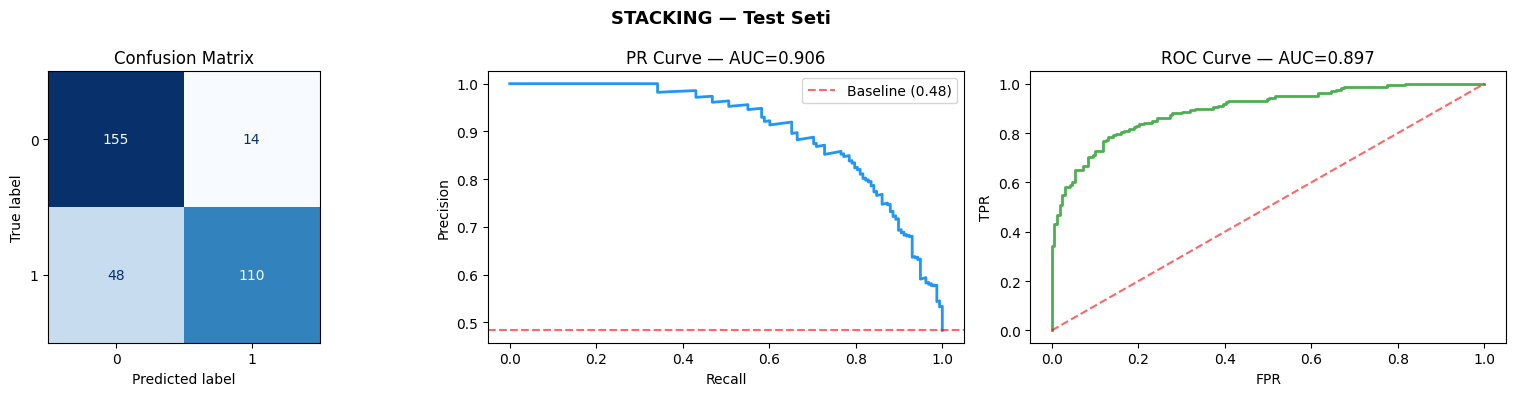

,PR-AUC,ROC-AUC,F1,Precision,Recall
Set,,,,,
val,0.8554,0.8955,0.7763,0.8252,0.7328
test,0.9061,0.8969,0.7801,0.8871,0.6962


In [16]:
all_candidates = {
    f"best_single ({best})": (best_model,   best_single_val_metrics),
    "voting_top2":           (voting_clf,   voting_val_metrics),
    "voting_top3":           (voting3_clf,  voting3_val_metrics),
    "stacking":              (stacking_clf, stacking_val_metrics),
    "blending":              (blending_clf, blending_val_metrics),
}

main_metric_key = "PR-AUC"
final_name  = max(all_candidates, key=lambda n: all_candidates[n][1].get(main_metric_key, 0))
final_model = all_candidates[final_name][0]
final_val   = all_candidates[final_name][1]

print("=== Final Model (val seti seçimi — sızıntısız) ===")
print(f"  Model       : {final_name}")
print(f"  Val {main_metric_key} : {final_val[main_metric_key]:.4f}")
print()

# evaluate_test yalnızca seçilen model için X_test üzerinde çağrılır
if "best_single" in final_name:
    final_metrics = test_metrics  # cell 2b97424c'de hesaplandı
else:
    final_metrics = evaluate_test(
        final_model, X_test, y_test, TASK_TYPE,
        final_name.replace(" ", "_").replace("(", "").replace(")", ""),
        cv_metrics      = results[best]["val"],
        experiment_name = EXPERIMENT_NAME,
        feature_version = FEATURE_VERSION,
        extra_tags      = {"selection_method": "val_based", "split_mode": SPLIT_MODE},
    )

display(pd.DataFrame([
    {"Set": "val",  **{k: round(v, 4) for k, v in final_val.items()}},
    {"Set": "test", **{k: round(v, 4) for k, v in final_metrics.items()}},
]).set_index("Set"))


In [17]:
import json, tempfile
from collections import defaultdict
from mlflow.tracking import MlflowClient

client = MlflowClient()
exp    = client.get_experiment_by_name(EXPERIMENT_NAME)

if exp:
    eid = exp.experiment_id

    # ── Champion Tracking ────────────────────────────────────────────
    # Yalnızca val_based seçim metoduyla kaydedilen run'lar — leaky_test etiketliler hariç
    val_based_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string=(
            f"tags.stage = 'test' "
            f"AND tags.feature_version = '{FEATURE_VERSION}' "
            f"AND tags.selection_method = 'val_based'"
        ),
        order_by=["metrics.test_pr_auc DESC"],
    )

    curr_score = final_metrics.get('PR-AUC', 0)

    if val_based_runs:
        champion   = val_based_runs[0]
        hist_score = champion.data.metrics.get('test_pr_auc', 0)
        delta      = curr_score - hist_score
        symbol     = "Yeni şampiyon!" if delta > 0 else "Geçilemedi"
        print("=== Champion Tracking (val_based) ===")
        print(f"  Geçmiş en iyi  : {hist_score:.4f}  ({champion.info.run_name})")
        print(f"  Mevcut         : {curr_score:.4f}  ({final_name})")
        print(f"  Fark           : {delta:+.4f}  — {symbol}")

        artifact_names = {a.path for a in client.list_artifacts(champion.info.run_id)}
        if "features.json" in artifact_names:
            try:
                with tempfile.TemporaryDirectory() as tmp:
                    path = client.download_artifacts(champion.info.run_id, "features.json", tmp)
                    with open(path) as f:
                        hist_features = set(json.load(f)["features"])
                curr_features = set(FEATURES)
                added   = sorted(curr_features - hist_features)
                removed = sorted(hist_features - curr_features)
                print(f"\n=== Feature Karşılaştırması ===")
                print(f"  Geçmiş : {len(hist_features)} feature")
                print(f"  Mevcut : {len(curr_features)} feature")
                if added:
                    print(f"  Eklenen  (+{len(added)}): {', '.join(added)}")
                if removed:
                    print(f"  Çıkarılan (-{len(removed)}): {', '.join(removed)}")
                if not added and not removed:
                    print("  Feature seti değişmedi.")
            except Exception:
                pass
        else:
            print("\n  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)")
    else:
        champion = None
        print("=== Champion Tracking (val_based) ===")
        print(f"  İlk val_based run — referans skor: {curr_score:.4f}  ({final_name})")
        print(f"  Feature sayısı: {len(FEATURES)}")

    # ── Genel MLflow Temizliği ────────────────────────────────────────

    # 1. Tüm test run'ları çek; leaky_test ve şampiyon korunur, diğerleri silinir
    all_test_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.stage = 'test'",
        order_by=["metrics.test_pr_auc DESC"],
    )
    champion_id = champion.info.run_id if champion else None
    stale_test  = [
        r for r in all_test_runs
        if r.info.run_id != champion_id
        and r.data.tags.get("selection_method") != "leaky_test"
    ]
    for r in stale_test:
        client.delete_run(r.info.run_id)
    if stale_test:
        print(f"\n✓ {len(stale_test)} eski test run'ı silindi — şampiyon ve leaky_test korundu")

    # 2. Summary, report, session — türetilmiş bilgi, tümünü sil
    for run_type in ("summary", "report", "session"):
        to_del = list(client.search_runs(
            experiment_ids=[eid],
            filter_string=f"tags.type = '{run_type}'",
        ))
        for r in to_del:
            client.delete_run(r.info.run_id)
        if to_del:
            print(f"✓ {len(to_del)} {run_type} run'ı silindi")

    # 3. Tuning — model başına en yüksek skoru koru (tüm era dahil)
    tuning_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'tuning'",
        order_by=["metrics.tuned_avg_prec DESC"],
    )
    by_model = defaultdict(list)
    for r in tuning_runs:
        by_model[r.data.tags.get("model_type", "unknown")].append(r)

    tuning_deleted = 0
    for runs in by_model.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            tuning_deleted += 1
    if tuning_deleted:
        print(f"✓ {tuning_deleted} eski tuning run'ı silindi — model başına 1 korundu")

    # 4. Baseline — model başına en son run'ı koru (tüm era dahil)
    baseline_runs = client.search_runs(
        experiment_ids=[eid],
        filter_string="tags.type = 'baseline'",
        order_by=["start_time DESC"],
    )
    by_model_bl = defaultdict(list)
    for r in baseline_runs:
        by_model_bl[r.data.tags.get("model_type", "unknown")].append(r)

    baseline_deleted = 0
    for runs in by_model_bl.values():
        for r in runs[1:]:
            client.delete_run(r.info.run_id)
            baseline_deleted += 1
    if baseline_deleted:
        print(f"✓ {baseline_deleted} eski baseline run'ı silindi — model başına 1 korundu")

    # 5. Bilinmeyen tip run'lar (feature_selection vb.) — tümünü sil
    known_types  = {"test_evaluation", "tuning", "baseline", "summary", "report", "session"}
    all_runs     = client.search_runs(experiment_ids=[eid])
    other_deleted = 0
    for r in all_runs:
        tags      = r.data.tags
        run_type  = tags.get("type", "")
        run_stage = tags.get("stage", "")
        is_known  = run_type in known_types or run_stage == "test"
        if not is_known and r.info.run_id != champion_id:
            client.delete_run(r.info.run_id)
            other_deleted += 1
    if other_deleted:
        print(f"✓ {other_deleted} diğer run silindi (feature_selection vb.)")

else:
    print(f"MLflow experiment '{EXPERIMENT_NAME}' bulunamadı.")


=== Champion Tracking (val_based) ===
  Geçmiş en iyi  : 0.9061  (test_eval_stacking_20260426_1914)
  Mevcut         : 0.9061  (stacking)
  Fark           : +0.0000  — Geçilemedi

  (Geçmiş şampiyonda features.json yok — karşılaştırma atlandı)

✓ 2 eski test run'ı silindi — şampiyon ve leaky_test korundu
✓ 1 summary run'ı silindi
✓ 1 report run'ı silindi
✓ 1 session run'ı silindi
✓ 3 eski tuning run'ı silindi — model başına 1 korundu
✓ 3 eski baseline run'ı silindi — model başına 1 korundu


## 9 — Temporal vs Random Split Karşılaştırması

`SPLIT_MODE = 'temporal'` altında model, **≥2014 yılı filmlerini** hiç görmeden eğitilir.
Bu, gerçek prodüksiyon senaryosunu simüle eder: model geçmiş verilerle eğitilir, gelecek filmler tahmin edilir.

### Split Özeti

| Split | Eğitim | Val | Test |
|-------|--------|-----|------|
| **random** | %70 (tüm dönemler) | %15 | %15 |
| **temporal** | ≤2009 — 2.281 film (%71, hit: %32,2) | 2010–2013 — 618 film (%19, hit: %37,5) | ≥2014 — 327 film (%10, hit: **%48,3**) |

⚠️ Test setindeki hit oranı (%48,3) train setinden (%32,2) belirgin şekilde yüksek → dağılım kayması mevcut. Metrikler random split ile doğrudan karşılaştırılamaz. **Dürüst genelleme tahmini: val PR-AUC = 0.855.**

### Sonuçlar

| Split | PR-AUC | ROC-AUC | F1 | Precision | Recall | Model |
|-------|--------|---------|-----|-----------|--------|-------|
| random (v6) | 0.8127 | 0.8693 | 0.7139 | 0.6848 | 0.7456 | voting_top2 |
| temporal (≥2013 test) | 0.8887 | 0.8980 | 0.8246 | 0.8117 | 0.8380 | voting_top2 |
| **temporal (≥2014 test)** | **0.9061** | **0.8969** | **0.7801** | 0.8871 | 0.6962 | **stacking** |

### Yorum

- **Val (2010–2013) PR-AUC = 0.8554**: Val seti 466 → 618 filme genişledi (ADVBK-71); metrik varyansı azaldı.
- **Test PR-AUC = 0.9061 vs Val = 0.8554**: Fark +0.051 — önemli kısmı **dağılım kaymasından** (test hit %48,3 vs train %32,2). Yüksek test metrikleri modeli değil dönem farkını yansıtıyor.
- **Stacking seçildi**: Val PR-AUC = 0.8554, Precision = 0.825 — ensemble çeşitliliği LGBM+RF+LogReg sinerjisini yakaladı.
- **`_hist_roi` geçerliliği**: Her satır için yalnızca `release_date` öncesi filmler kullanılmıştı; temporal split altında sızıntı yok.
- **Sonuç**: Feature seti ≥2014 dönemine dayanıklı. Dürüst üst sınır val PR-AUC ≈ 0.855; test metrikleri referans değil.

## 8 — SHAP Analizi

`voting_top3` modelinin LightGBM bileşeni üzerinden her özelliğin katkı yönü ve büyüklüğü hesaplanıyor.

**Kontrol listesi:**

| Soru | Özellik |
|---|---|
| Leakage riski var mı? | `kw_aftercreditsstinger`, `kw_duringcreditsstinger` |
| Budget çakışması | `relative_budget_score` drop edildi (ADVBK-61, r=0.781) |
| Tarihsel sinyal güçlü mü? | `director_hist_roi`, `actor_hist_roi` |


In [18]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# SHAP analizi için her zaman voting3_clf kullan (v4 hedef modeli)
_shap_clf = voting3_clf
_lgbm = _shap_clf.named_estimators_.get(
    'lgbm',
    next(
        est for name, est in zip(
            [n for n, _ in _shap_clf.estimators],
            _shap_clf.estimators_
        )
        if 'lightgbm' in str(type(est)).lower()
    )
)

explainer  = shap.TreeExplainer(_lgbm)
shap_raw   = explainer.shap_values(X_test)

# Binary sınıflandırma: list[class0, class1] veya tek array
if isinstance(shap_raw, list):
    sv = shap_raw[1]   # hit sınıfı katkıları
else:
    sv = shap_raw

feature_names = X_test.columns.tolist()
mean_abs = np.abs(sv).mean(axis=0)
mean_val = sv.mean(axis=0)

shap_df = pd.DataFrame({
    'feature'       : feature_names,
    'mean_abs_shap' : mean_abs,
    'mean_shap'     : mean_val,
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

shap_df['direction'] = shap_df['mean_shap'].apply(
    lambda x: '↑ hit' if x > 0 else '↓ miss'
)



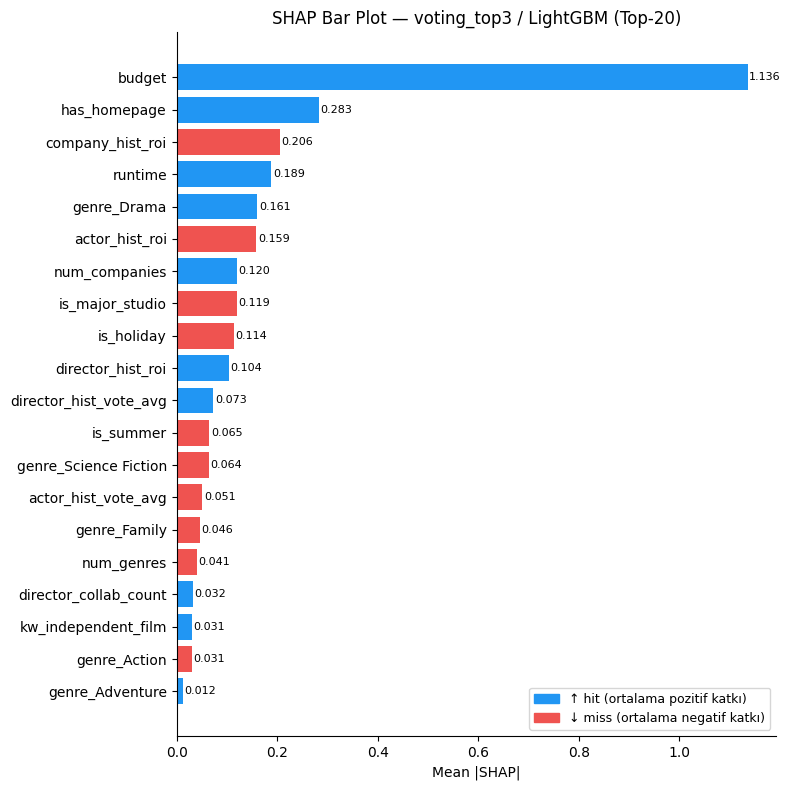

In [19]:
fig, ax = plt.subplots(figsize=(8, 8))
top_n = 20
df_plot = shap_df.head(top_n).sort_values('mean_abs_shap')

colors = ['#2196F3' if d == '↑ hit' else '#EF5350' for d in df_plot['direction']]
bars = ax.barh(df_plot['feature'], df_plot['mean_abs_shap'], color=colors)

for bar, val in zip(bars, df_plot['mean_abs_shap']):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=8)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2196F3', label='↑ hit (ortalama pozitif katkı)'),
    Patch(color='#EF5350', label='↓ miss (ortalama negatif katkı)'),
], loc='lower right', fontsize=9)

ax.set_xlabel('Mean |SHAP|')
ax.set_title('SHAP Bar Plot — voting_top3 / LightGBM (Top-20)')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [20]:
print("=== Leakage & Çakışma Kontrol ===\n")

# Bilinen post-release feature'lar — film izlendikten veya yayınlandıktan sonra oluşur.
# Buraya eklenen her feature modelde varsa otomatik olarak leakage olarak raporlanır.
POST_RELEASE_FEATURES = {
    # TMDB kullanıcı aktivitesi
    'popularity', 'vote_average', 'vote_count',
    # Film izlenmesini gerektiren özellikler
    'has_postcredit',
    # Post-credit sahnesi tag'leri — kullanıcılar izledikten sonra ekler
    'kw_aftercreditsstinger', 'kw_duringcreditsstinger',
    # İzleyici yorumuna dayalı içerik etiketleri
    'kw_murder', 'kw_dystopia', 'kw_rape', 'kw_nudity',
    'kw_violence', 'kw_torture', 'kw_suicide',
}

OVERLAP_CORR_THRESHOLD = 0.70
HIST_ROI_PATTERN       = '_hist_roi'

num_features    = [f for f in feature_names if X_test[f].nunique() > 2]

# ── 1. Leakage: whitelist kontrolü ──────────────────────────────────────────
in_model     = [f for f in POST_RELEASE_FEATURES if f in feature_names]
already_drop = [f for f in POST_RELEASE_FEATURES if f not in feature_names]

print(f"Leakage Kontrolü — {len(POST_RELEASE_FEATURES)} bilinen post-release feature\n")

if in_model:
    print("  ⚠️  Modelde post-release feature var:")
    for feat in in_model:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"    {feat:<35}  #{rank:<3}  mean_abs={mas:.4f}  "
              f"shap_hit={shap_hit:+.4f}  shap_miss={shap_miss:+.4f}")
    print(f"\n  → Aksiyon: bu {len(in_model)} feature'ı BASE_FEATURES veya tmdb_model.csv'den çıkarın.")
else:
    print("  ✅  Modelde bilinen post-release feature yok.")

print(f"\n  (Modelde yer almayan post-release feature: {len(already_drop)} adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)")  

# ── 2. Çakışma: continuous feature'lar arası SHAP korelasyonu ───────────────
print(f"\nSHAP Korelasyon Matrisi (eşik |r| > {OVERLAP_CORR_THRESHOLD}):\n")

overlap_pairs = []
checked = set()
for i, fa in enumerate(num_features):
    for fb in num_features[i+1:]:
        if (fa, fb) in checked:
            continue
        checked.add((fa, fb))
        idx_a = feature_names.index(fa)
        idx_b = feature_names.index(fb)
        r = np.corrcoef(sv[:, idx_a], sv[:, idx_b])[0, 1]
        if abs(r) > OVERLAP_CORR_THRESHOLD:
            rank_a = shap_df[shap_df['feature'] == fa].index[0] + 1
            rank_b = shap_df[shap_df['feature'] == fb].index[0] + 1
            overlap_pairs.append((fa, fb, r, rank_a, rank_b))

if overlap_pairs:
    overlap_pairs.sort(key=lambda x: -abs(x[2]))
    for fa, fb, r, ra, rb in overlap_pairs:
        print(f"  {fa} (#{ra}) ↔ {fb} (#{rb})  r={r:.3f}  "
              f"⚠️  Örtüşen bilgi — birini çıkarmayı değerlendirin")
else:
    print(f"  Eşik üzerinde çakışan çift yok.")

# ── 3. Tarihsel sinyal: *_hist_roi pattern ──────────────────────────────────
print(f"\nTarihsel ROI katkısı (*{HIST_ROI_PATTERN}):\n")

roi_features = [f for f in feature_names if f.endswith(HIST_ROI_PATTERN)]
if not roi_features:
    print(f"  {HIST_ROI_PATTERN} pattern'ine uyan feature yok.")
else:
    for feat in roi_features:
        idx       = feature_names.index(feat)
        rank      = shap_df[shap_df['feature'] == feat].index[0] + 1
        mas       = float(np.abs(sv[:, idx]).mean())
        drct      = shap_df[shap_df['feature'] == feat]['direction'].values[0]
        shap_hit  = sv[y_test.values == 1, idx].mean()
        shap_miss = sv[y_test.values == 0, idx].mean()
        print(f"  {feat:<30}  #{rank}  mean_abs={mas:.4f}  "
              f"hit_avg={shap_hit:+.4f}  miss_avg={shap_miss:+.4f}  yön={drct}")
    print("\n  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).")
    print("       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.")


=== Leakage & Çakışma Kontrol ===

Leakage Kontrolü — 13 bilinen post-release feature

  ✅  Modelde bilinen post-release feature yok.

  (Modelde yer almayan post-release feature: 13 adet — bunların büyük çoğunluğu BASE_FEATURES'e hiç alınmadı)

SHAP Korelasyon Matrisi (eşik |r| > 0.7):

  Eşik üzerinde çakışan çift yok.

Tarihsel ROI katkısı (*_hist_roi):

  director_hist_roi               #10  mean_abs=0.1037  hit_avg=+0.0444  miss_avg=-0.0022  yön=↑ hit
  actor_hist_roi                  #6  mean_abs=0.1587  hit_avg=-0.0825  miss_avg=-0.1258  yön=↓ miss
  company_hist_roi                #3  mean_abs=0.2058  hit_avg=+0.0187  miss_avg=-0.1154  yön=↓ miss

  Not: Ortalama yön sıfır-ağırlıklı olabilir (çoğu film için hist_roi=0).
       hit_avg vs miss_avg farkı gerçek sinyal gücünü gösterir.


## 10 — Kalibrasyon Analizi + Eşik Optimizasyonu

**Amaç:** `final_model`'in olasılık tahminlerinin güvenilirliğini ölçmek (Brier skoru + kalibrasyon eğrisi) ve sınıf dengesizliği nedeniyle 0.50 yerine daha uygun bir karar eşiği bulmak.

- **Kalibrasyon eğrisi**: Tahmin edilen olasılık vs gerçek hit oranı — iyi kalibre modelde eğri köşegene yakın olmalı.
- **Brier skoru**: `mean((p - y)²)` — düşük = daha iyi.
- **Eşik optimizasyonu**: Val seti üzerinde F1 maksimize eden eşiği bul; test setine uygula.

=== Brier Skoru ===
  Val:      0.1233
  Test:     0.1356
  Baseline: 0.2345  (naif sınıf oranı tahmini)


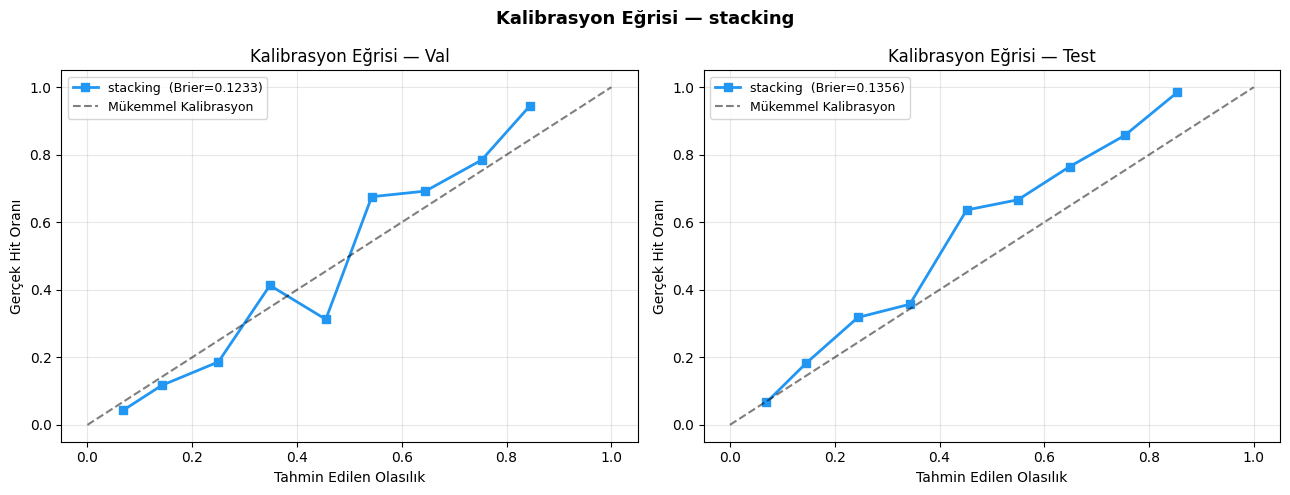

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    brier_score_loss, f1_score, precision_score, recall_score,
    precision_recall_curve,
)

y_prob_val  = final_model.predict_proba(X_val)[:, 1]
y_prob_test = final_model.predict_proba(X_test)[:, 1]

brier_val      = brier_score_loss(y_val, y_prob_val)
brier_test     = brier_score_loss(y_test, y_prob_test)
brier_baseline = brier_score_loss(y_val, np.full(len(y_val), y_val.mean()))

print("=== Brier Skoru ===")
print(f"  Val:      {brier_val:.4f}")
print(f"  Test:     {brier_test:.4f}")
print(f"  Baseline: {brier_baseline:.4f}  (naif sınıf oranı tahmini)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f"Kalibrasyon Eğrisi — {final_name}", fontsize=13, fontweight="bold")

for ax, split_name, y_true, y_prob in [
    (axes[0], "Val",  y_val,  y_prob_val),
    (axes[1], "Test", y_test, y_prob_test),
]:
    frac_pos, mean_pred = calibration_curve(y_true, y_prob, n_bins=10)
    ax.plot(mean_pred, frac_pos, "s-", color="#2196F3", lw=2,
            label=f"{final_name}  (Brier={brier_score_loss(y_true, y_prob):.4f})")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Mükemmel Kalibrasyon")
    ax.set(xlabel="Tahmin Edilen Olasılık", ylabel="Gerçek Hit Oranı",
           title=f"Kalibrasyon Eğrisi — {split_name}")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# --- Eşik Optimizasyonu (Val seti üzerinde) ---
prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_val, y_prob_val)
f1_arr = np.where(
    (prec_arr + rec_arr) > 0,
    2 * prec_arr * rec_arr / (prec_arr + rec_arr),
    0.0,
)

best_idx  = int(np.argmax(f1_arr[:-1]))
best_thr  = float(thresh_arr[best_idx])
best_f1   = float(f1_arr[best_idx])
best_prec = float(prec_arr[best_idx])
best_rec  = float(rec_arr[best_idx])

print("=== Val Seti — Eşik Optimizasyonu ===")
y_pred_def_val = (y_prob_val >= 0.50).astype(int)
print(f"  Varsayılan (0.50): F1={f1_score(y_val, y_pred_def_val):.4f}  "
      f"P={precision_score(y_val, y_pred_def_val):.4f}  "
      f"R={recall_score(y_val, y_pred_def_val):.4f}")
print(f"  Optimal ({best_thr:.3f}):    F1={best_f1:.4f}  "
      f"P={best_prec:.4f}  R={best_rec:.4f}")

# --- Test setine uygula ---
y_pred_def_test = (y_prob_test >= 0.50).astype(int)
y_pred_opt_test = (y_prob_test >= best_thr).astype(int)

cmp_rows = [
    {"Eşik": 0.50, "F1": f1_score(y_test, y_pred_def_test),
     "Precision": precision_score(y_test, y_pred_def_test),
     "Recall": recall_score(y_test, y_pred_def_test)},
    {"Eşik": round(best_thr, 3), "F1": f1_score(y_test, y_pred_opt_test),
     "Precision": precision_score(y_test, y_pred_opt_test),
     "Recall": recall_score(y_test, y_pred_opt_test)},
]
from IPython.display import display
print("\n=== Test Seti Karşılaştırması ===")
display(pd.DataFrame(cmp_rows).round(4).set_index("Eşik"))

OPTIMAL_THRESHOLD = round(best_thr, 3)
print(f"\n✓ OPTIMAL_THRESHOLD = {OPTIMAL_THRESHOLD}")

=== Val Seti — Eşik Optimizasyonu ===
  Varsayılan (0.50): F1=0.7763  P=0.8252  R=0.7328
  Optimal (0.466):    F1=0.7849  P=0.8082  R=0.7629

=== Test Seti Karşılaştırması ===


,F1,Precision,Recall
Eşik,,,
0.500,0.7801,0.8871,0.6962
0.466,0.7931,0.8712,0.7278



✓ OPTIMAL_THRESHOLD = 0.466


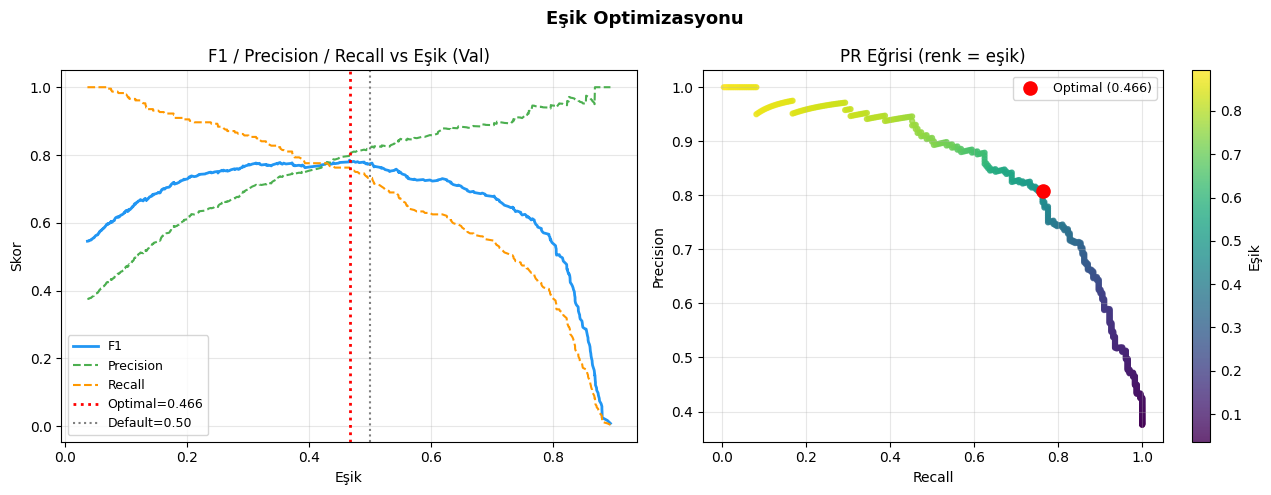

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Eşik Optimizasyonu", fontsize=13, fontweight="bold")

# Sol: F1 / Precision / Recall vs eşik
axes[0].plot(thresh_arr, f1_arr[:-1],   color="#2196F3", lw=2,   label="F1")
axes[0].plot(thresh_arr, prec_arr[:-1], color="#4CAF50", lw=1.5, linestyle="--", label="Precision")
axes[0].plot(thresh_arr, rec_arr[:-1],  color="#FF9800", lw=1.5, linestyle="--", label="Recall")
axes[0].axvline(best_thr, color="red",  linestyle=":", lw=2, label=f"Optimal={best_thr:.3f}")
axes[0].axvline(0.50,     color="gray", linestyle=":", lw=1.5, label="Default=0.50")
axes[0].set(xlabel="Eşik", ylabel="Skor",
            title="F1 / Precision / Recall vs Eşik (Val)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Sağ: PR eğrisi (eşikle renklendirilmiş)
sc = axes[1].scatter(rec_arr[:-1], prec_arr[:-1], c=thresh_arr,
                     cmap="viridis", s=12, alpha=0.8)
axes[1].scatter([best_rec], [best_prec], color="red", s=90, zorder=5,
                label=f"Optimal ({best_thr:.3f})")
plt.colorbar(sc, ax=axes[1], label="Eşik")
axes[1].set(xlabel="Recall", ylabel="Precision",
            title="PR Eğrisi (renk = eşik)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()